## Step 1 – Imports
טעינת כל הספריות הדרושות לפרויקט:

- pandas, numpy – עבודה עם נתונים וטבלאות  
- train_test_split – חלוקת הדאטה ל-Train/Validation/Test  
- TfidfVectorizer – יצירת ייצוג TF-IDF מהטקסט  
- LogisticRegression, MultinomialNB – מודלי הסיווג בהם נשתמש  
- metrics – חישוב דיוק, F1 ומטריצות בלבול  
- matplotlib, seaborn – ויזואליזציה וגרפים  
- warnings – הסתרת התראות לא רצויות בזמן הריצה  


In [1]:
# =========================
# Step 1: Imports
# =========================

import pandas as pd            
import numpy as np            
from sklearn.model_selection import train_test_split  

from sklearn.feature_extraction.text import TfidfVectorizer  
from sklearn.linear_model import LogisticRegression          
from sklearn.naive_bayes import MultinomialNB                

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix  

import matplotlib.pyplot as plt   
import seaborn as sns             

import warnings                  
warnings.filterwarnings("ignore")


## Step 2 – Load the Dataset
בשלב זה אנו טוענים את קובץ ה־CSV המכיל את הדאטה.

- הגדרת `file_path` כנתיב לקובץ הנתונים.  
- טעינת הקובץ אל DataFrame באמצעות `pd.read_csv`.  
- הצגת צורת הדאטה (מספר שורות ועמודות).  
- הדפסת שמות העמודות לצורך הכרות עם מבנה הדאטה.  
- הגדרת עמודת התווית (`rating`) ובדיקת התפלגות הערכים בה.  


In [2]:
# =========================
# Step 2: Load the dataset
# =========================


file_path = "step_5.csv"


df = pd.read_csv(file_path)


print("Dataset shape (rows, columns):", df.shape)


df.head()
print(df.columns)
label_col = "rating"  
df[label_col].value_counts().sort_index()

Dataset shape (rows, columns): (9999, 8)
Index(['category', 'review', 'rating', 'text_length', 'text_partial',
       'tokens_partial', 'text_full', 'tokens_full'],
      dtype='object')


rating
1    2038
2    1956
3    2055
4    1962
5    1988
Name: count, dtype: int64

## Step 5 – Keep Only Useful Columns
בשלב זה אנו יוצרים DataFrame חדש שמכיל רק את העמודות הדרושות למודל:

- `text_full` – הטקסט המלא של הביקורת  
- `tokens_full` – גרסת הטוקנים לאחר ניקוי  
- `rating` – התווית (Label)

פעולה זו מפשטת את הדאטה ומכינה אותו לעיבוד בשלבים הבאים.


In [3]:
# =========================
# Step 5: Keep only useful columns
# =========================

df_clean = df[['text_full', 'tokens_full', 'rating']].copy()

print(df_clean.shape)
df_clean.head()

(9999, 3)


,text_full,tokens_full,rating
0,thoroughly impressed rolly rider rideon toy br...,"['thoroughly', 'impressed', 'rolly', 'rider', ...",4
1,strongly unpleasant experience food gift flowe...,"['strongly', 'unpleasant', 'experience', 'food...",1
2,purchase fresh prep essential food processor o...,"['purchase', 'fresh', 'prep', 'essential', 'fo...",2
3,recently purchase blissbrewer automatic coffee...,"['recently', 'purchase', 'blissbrewer', 'autom...",5
4,absolutely hate experience buckhunter pro clai...,"['absolutely', 'hate', 'experience', 'buckhunt...",1


## Fix 1 – Convert `tokens_full` into Proper Token Lists
המטרה של שלב זה היא להבטיח כי העמודה `tokens_full` אכן מכילה רשימות של טוקנים (מילים), ולא מחרוזות או פורמטים אחרים.

הפעולות בקטע זה:
- הגדרת פונקציה `ensure_list_of_tokens` שמזהה האם הערך הוא:
  - רשימה תקינה → מחזירה כפי שהוא  
  - מחרוזת שמייצגת רשימה → מומרים באמצעות `ast.literal_eval`  
  - מחרוזת רגילה → מפוצלת למילים  
  - טיפוס אחר → מומר למחרוזת ומפוצל  
- החלת הפונקציה על כל העמודה `tokens_full`.  
- בדיקה שהפלט אכן רשימת טוקנים תקינה.  


In [4]:
# =========================
# FIX 1: Force tokens_full to be a real list of tokens
# =========================

import ast

def ensure_list_of_tokens(x):
    if isinstance(x, list):
        return [str(t) for t in x]

    if isinstance(x, str):
        s = x.strip()

        try:
            if s.startswith('[') and s.endswith(']'):
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(t) for t in parsed]
        except Exception:
            pass

        return s.split()

    return str(x).split()

df_clean['tokens_full'] = df_clean['tokens_full'].apply(ensure_list_of_tokens)


print(type(df_clean['tokens_full'].iloc[0]))
print(df_clean['tokens_full'].iloc[0][:10])
print(type(df_clean['tokens_full'].iloc[0][0]))

<class 'list'>
['thoroughly', 'impressed', 'rolly', 'rider', 'rideon', 'toy', 'brought', 'endless', 'joy', 'little']
<class 'str'>


## Fix 2 – Recreate Splits for Text, Tokens, and Labels
בשלב זה אנו יוצרים מחדש את מערכי הקלט והתוויות לאחר תיקון הטוקנים:

- הגדרת משתני הקלט:
  - `X_text` – טקסט הביקורת המלא  
  - `X_tokens` – רשימות הטוקנים  
  - `y` – דירוג הביקורת  
- חלוקה מחודשת של הדאטה לסטים:
  - 80% Train  
  - 10% Validation  
  - 10% Test  
- שימוש ב־`stratify` כדי לשמור על התפלגות הדירוגים בכל הסטים.  
- הדפסת גודל כל סט לצורך אימות.


In [5]:
# =========================
# FIX 2: Recreate X_text, X_tokens, y and split again
# =========================

from sklearn.model_selection import train_test_split

X_text = df_clean['text_full']
X_tokens = df_clean['tokens_full']
y = df_clean['rating']

X_text_train, X_text_temp, X_tokens_train, X_tokens_temp, y_train, y_temp = train_test_split(
    X_text,
    X_tokens,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_text_val, X_text_test, X_tokens_val, X_tokens_test, y_val, y_test = train_test_split(
    X_text_temp,
    X_tokens_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train size:", len(y_train))
print("Validation size:", len(y_val))
print("Test size:", len(y_test))

Train size: 7999
Validation size: 1000
Test size: 1000


## Check Token Format in Training Sample
מטרת התא זו היא לוודא שעמודת הטוקנים אכן בפורמט הנכון לאחר פעולות הניקוי:

- שליפת רשימת הטוקנים הראשונה מתוך סט האימון.  
- בדיקת סוג המשתנה (`list`).  
- הדפסת 10 הטוקנים הראשונים כדוגמה.  
- בדיקת סוג כל טוקן בודד (`str`).  

צעד זה מאשר שהטוקנים מוכנים לשימוש במודלים בהמשך.


In [6]:
x = X_tokens_train.iloc[0]
print(type(x))       
print(x[:10])        
print(type(x[0]))    
print(x[0])        

<class 'list'>
['recently', 'subscribed', 'beauty', 'box', 'delivers', 'monthly', 'assortment', 'beauty', 'product', 'doorstep']
<class 'str'>
recently


## Step 7 – TF-IDF Representation
בשלב זה אנו ממירים את טקסט הביקורות לייצוג מספרי באמצעות TF-IDF:

- שימוש ב־`TfidfVectorizer` עם:
  - `max_features=20000` – הגבלת גודל הווקבולרי  
  - `ngram_range=(1,1)` – שימוש במילים יחידות (Unigrams)  
  - `min_df=5` – התעלמות ממילים נדירות במיוחד  
- התאמת הוקטורייזר על סט האימון בלבד (`fit_transform`).  
- המרת סט הוולידציה והטסט באמצעות אותו וקטורייזר (`transform`).  
- הדפסת צורת מטריצות ה־TF-IDF לכל סט.  


In [7]:
# =========================
# Step 7: TF-IDF Representation
# =========================

X_train_text = X_text_train
X_val_text   = X_text_val
X_test_text  = X_text_test

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,  
    ngram_range=(1, 1),  
    min_df=5             
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf   = tfidf_vectorizer.transform(X_val_text)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF val shape:  ", X_val_tfidf.shape)
print("TF-IDF test shape: ", X_test_tfidf.shape)

TF-IDF train shape: (7999, 6352)
TF-IDF val shape:   (1000, 6352)
TF-IDF test shape:  (1000, 6352)


## Step 7B-1 – Verify Token List Format
בדיקה נוספת לוודא שעמודת `tokens_full` אכן מכילה רשימות תקינות לאחר הניקוי:

- הצגת סוג הערך הראשון בעמודה (`list`).  
- הדפסת 100 הטוקנים הראשונים כדוגמה.  

שלב זה נועד לאשר שהנתונים מוכנים לשימוש עבור Word2Vec בהמשך.


In [8]:
# =========================
# Step 7B-1 (fixed): Check type of tokens_full
# =========================

print(type(df_clean['tokens_full'].iloc[0]))
print(df_clean['tokens_full'].iloc[0][:100])

<class 'list'>
['thoroughly', 'impressed', 'rolly', 'rider', 'rideon', 'toy', 'brought', 'endless', 'joy', 'little', 'vibrant', 'color', 'smooth', 'glide', 'motion', 'child', 'really', 'stood', 'fact', 'come', 'interchangeable', 'wheel', 'allow', 'child', 'imagine', 'different', 'scenario', 'explore', 'creativity', 'rolly', 'rider', 'big', 'hit', 'family', 'gathering', 'playdates', 'want', 'turn', 'suggestion', 'add', 'storage', 'extra', 'wheel', 'child', 'tends', 'scatter', 'room', 'overall', 'rolly', 'rider', 'topnotch', 'rideon', 'toy', 'highly', 'recommend', 'look', 'fun', 'engage', 'way', 'encourage', 'child', 'imagination', 'physical', 'activity']


## Step 7B-2 – Prepare Tokenized Sentences for Word2Vec
בשלב זה מכינים את הנתונים לאימון מודל Word2Vec:

- המרת עמודות הטוקנים (`X_tokens_train/val/test`) לרשימות של משפטים (רשימות טוקנים).  
- יצירת שלושה סטים: Train, Validation, Test.  
- הדפסת מספר המשפטים בכל סט לאימות.  
- הצגת 10 הטוקנים הראשונים כדוגמה.  

הנתונים כעת מוכנים להזנתם למודל Word2Vec.


In [9]:
# =========================
# Step 7B-2 (clean): Prepare sentences for Word2Vec
# =========================

sentences_train = X_tokens_train.tolist()
sentences_val   = X_tokens_val.tolist()
sentences_test  = X_tokens_test.tolist()

print(len(sentences_train), len(sentences_val), len(sentences_test))

print("first 10 tokens:", x[:10])

7999 1000 1000
first 10 tokens: ['recently', 'subscribed', 'beauty', 'box', 'delivers', 'monthly', 'assortment', 'beauty', 'product', 'doorstep']


## Step 7B-3 – Train Word2Vec Model
בשלב זה מאמנים מודל Word2Vec על משפטי ה־Train:

- הגדרת פרמטרים:
  - `vector_size=100` – גודל הווקטור לכל מילה  
  - `window=5` – גודל חלון ההקשר  
  - `min_count=5` – התעלמות ממילים נדירות  
  - `sg=0` – שימוש במודל CBOW  
- אימון המודל על רשימות הטוקנים.  
- הדפסת גודל הווקבולרי שנלמד.  
- הדגמת וקטור עבור מילה נפוצה (אם קיימת במודל).  

מודל זה ישמש לאחר מכן ליצירת ייצוג וקטורי למסמכים.


In [10]:
!pip install gensim

In [11]:
# =========================
# Step 7B-3: Train Word2Vec model
# =========================

from gensim.models import Word2Vec

w2v_size = 100     
w2v_window = 5      
w2v_min_count = 5   
w2v_workers = 4     

w2v_model = Word2Vec(
    sentences=sentences_train, 
    vector_size=w2v_size,
    window=w2v_window,
    min_count=w2v_min_count,
    workers=w2v_workers,
    sg=0   
)

print("W2V vocab size:", len(w2v_model.wv.index_to_key))

example_word = 'good'
if example_word in w2v_model.wv:
    print(f"Vector for '{example_word}' (first 10 values):")
    print(w2v_model.wv[example_word][:10])
else:
    print(f"'{example_word}' not in vocabulary")

W2V vocab size: 6997
Vector for 'good' (first 10 values):
[-1.7543751  -0.46905664 -0.9338971   0.34578508  0.27804387 -1.0019318
 -0.2023129  -0.522217    0.0921532   1.7649527 ]


## Step 7B-4 – Create Document Vectors Using Averaged Word2Vec
בשלב זה ממירים כל ביקורת לווקטור יחיד באמצעות ממוצע וקטורי המילים שלה:

- הגדרת פונקציה `document_vector`:
  - מסננת רק מילים שקיימות בווקבולרי של Word2Vec.  
  - אם אין מילים תקפות – מוחזרת וקטור אפסים.  
  - מחשבת ממוצע של כל וקטורי המילים התקפות.  
- יצירת מטריצות מסמכים (Train, Validation, Test) באמצעות הפונקציה.  
- הדפסת צורת המטריצות לצורך אימות.

ייצוג זה ישמש לאימון מודלים מבוססי Word2Vec.


In [12]:
# =========================
# Step 7B-4: Build document vectors using average Word2Vec
# =========================

import numpy as np

def document_vector(tokens, model, vector_size):
    
    valid_tokens = [word for word in tokens if word in model.wv]
    if not valid_tokens:
        return np.zeros(vector_size)

    vectors = np.array([model.wv[word] for word in valid_tokens])
    return vectors.mean(axis=0)

X_train_w2v = np.vstack([
    document_vector(tokens, w2v_model, w2v_size)
    for tokens in sentences_train
])

X_val_w2v = np.vstack([
    document_vector(tokens, w2v_model, w2v_size)
    for tokens in sentences_val
])

X_test_w2v = np.vstack([
    document_vector(tokens, w2v_model, w2v_size)
    for tokens in sentences_test
])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec val shape:  ", X_val_w2v.shape)
print("Word2Vec test shape: ", X_test_w2v.shape)

Word2Vec train shape: (7999, 100)
Word2Vec val shape:   (1000, 100)
Word2Vec test shape:  (1000, 100)


## Step 8 – Model Training and Evaluation (Classical Models)

בשלב זה אנו מאמנים *מודלים קלאסיים* (Logistic Regression ו־Multinomial Naive Bayes)
על שני הייצוגים שהכנו:

- ייצוג **TF-IDF** של הטקסטים
- ייצוג **Word2Vec** (ממוצע וקטורי המילים בכל ביקורת)

בכל מודל נחשב:
- דיוק (Accuracy)
- F1-macro
- Confusion Matrix
- Classification Report

הקוד כאן כתוב בסגנון דומה למחברות הדוגמה (Email Classification),
אבל מותאם לדאטה של הביקורות (`rating`).

## Step 8B – Train and Evaluate Models Using TF-IDF

בשלב זה נאמן שני מודלים על ייצוג ה־TF-IDF ונשווה את ביצועיהם:

### 1. TF-IDF + Logistic Regression
- אימון מודל Logistic Regression על וקטורי ה־TF-IDF.
- חישוב Accuracy ו־F1-macro על סטי ה־Validation וה־Test.
- הפקת Confusion Matrix ו־Classification Report.

### 2. TF-IDF + Multinomial Naive Bayes
- אימון מודל Naive Bayes מסוג Multinomial על אותו הייצוג.
- חישוב אותם מדדי ביצוע לצורך השוואה ברורה בין שני המודלים.

=== Logistic Regression + TF-IDF ===
Validation accuracy: 0.966
Validation F1-macro: 0.965713878757357

Test accuracy: 0.951
Test F1-macro: 0.9506517801577189

Confusion Matrix (Test, LR + TF-IDF):
[[189  15   0   0   0]
 [  4 192   0   0   0]
 [  0   1 204   0   0]
 [  0   0   0 179  17]
 [  0   0   1  11 187]]


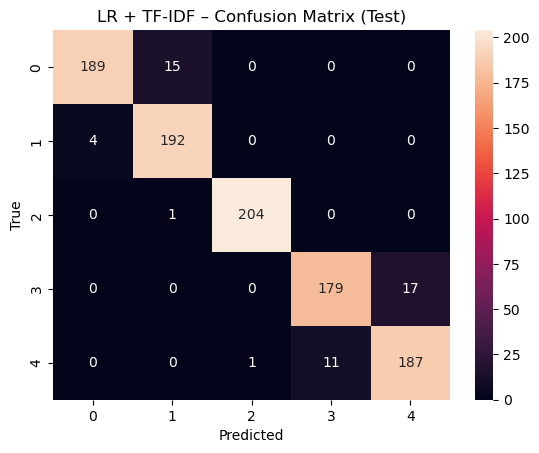


Classification Report (Test, LR + TF-IDF):
              precision    recall  f1-score   support

           1       0.98      0.93      0.95       204
           2       0.92      0.98      0.95       196
           3       1.00      1.00      1.00       205
           4       0.94      0.91      0.93       196
           5       0.92      0.94      0.93       199

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


=== Multinomial Naive Bayes + TF-IDF ===
Validation accuracy: 0.884
Validation F1-macro: 0.8826019556000579

Test accuracy: 0.877
Test F1-macro: 0.8756127701183427

Confusion Matrix (Test, NB + TF-IDF):
[[188  16   0   0   0]
 [ 22 172   2   0   0]
 [  0   0 205   0   0]
 [  0   0   0 147  49]
 [  0   0   0  34 165]]


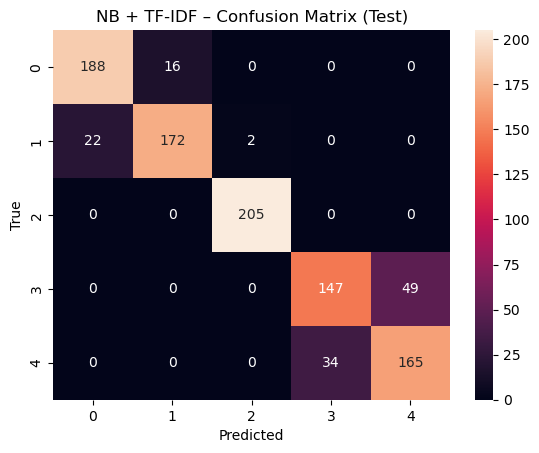


Classification Report (Test, NB + TF-IDF):
              precision    recall  f1-score   support

           1       0.90      0.92      0.91       204
           2       0.91      0.88      0.90       196
           3       0.99      1.00      1.00       205
           4       0.81      0.75      0.78       196
           5       0.77      0.83      0.80       199

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [13]:
# =========================
# Step 8B: TF-IDF + Logistic Regression & MultinomialNB
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -------- Logistic Regression + TF-IDF --------
lr_tfidf = LogisticRegression(C=10, max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

# Validation predictions
y_val_pred_lr_tfidf = lr_tfidf.predict(X_val_tfidf)
# Test predictions
y_test_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("=== Logistic Regression + TF-IDF ===")
print("Validation accuracy:", accuracy_score(y_val, y_val_pred_lr_tfidf))
print("Validation F1-macro:", f1_score(y_val, y_val_pred_lr_tfidf, average="macro"))
print("\nTest accuracy:", accuracy_score(y_test, y_test_pred_lr_tfidf))
print("Test F1-macro:", f1_score(y_test, y_test_pred_lr_tfidf, average="macro"))

cm_lr_tfidf = confusion_matrix(y_test, y_test_pred_lr_tfidf)
print("\nConfusion Matrix (Test, LR + TF-IDF):")
print(cm_lr_tfidf)

plt.figure()
sns.heatmap(cm_lr_tfidf, annot=True, fmt="d")
plt.title("LR + TF-IDF – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Test, LR + TF-IDF):")
print(classification_report(y_test, y_test_pred_lr_tfidf))

# -------- Multinomial Naive Bayes + TF-IDF --------
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# Validation predictions
y_val_pred_nb_tfidf = nb_tfidf.predict(X_val_tfidf)
# Test predictions
y_test_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("\n=== Multinomial Naive Bayes + TF-IDF ===")
print("Validation accuracy:", accuracy_score(y_val, y_val_pred_nb_tfidf))
print("Validation F1-macro:", f1_score(y_val, y_val_pred_nb_tfidf, average="macro"))
print("\nTest accuracy:", accuracy_score(y_test, y_test_pred_nb_tfidf))
print("Test F1-macro:", f1_score(y_test, y_test_pred_nb_tfidf, average="macro"))

cm_nb_tfidf = confusion_matrix(y_test, y_test_pred_nb_tfidf)
print("\nConfusion Matrix (Test, NB + TF-IDF):")
print(cm_nb_tfidf)

plt.figure()
sns.heatmap(cm_nb_tfidf, annot=True, fmt="d")
plt.title("NB + TF-IDF – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Test, NB + TF-IDF):")
print(classification_report(y_test, y_test_pred_nb_tfidf))


## Step 8C – Train and Evaluate Models Using Word2Vec

כאן נאמן מודלים על ייצוג מבוסס Word2Vec (ממוצע וקטורי המילים בכל ביקורת):

- Logistic Regression – מתאים באופן טבעי לוקטורים רציפים (כולל ערכים שליליים).
- Multinomial Naive Bayes – דורש פיצ'רים אי-שליליים, ולכן נבצע הסטה (shift)
  של הווקטורים כך שכל הערכים יהיו חיוביים לפני האימון.

מטרת השלב היא להשוות את ייצוג Word2Vec לייצוג TF-IDF עבור אותם המודלים.

=== Logistic Regression + Word2Vec ===
Validation accuracy: 0.931
Validation F1-macro: 0.9304405685141719

Test accuracy: 0.92
Test F1-macro: 0.9194046829097371

Confusion Matrix (Test, LR + Word2Vec):
[[189  15   0   0   0]
 [  8 181   5   2   0]
 [  0   3 202   0   0]
 [  0   0   0 171  25]
 [  0   0   1  21 177]]


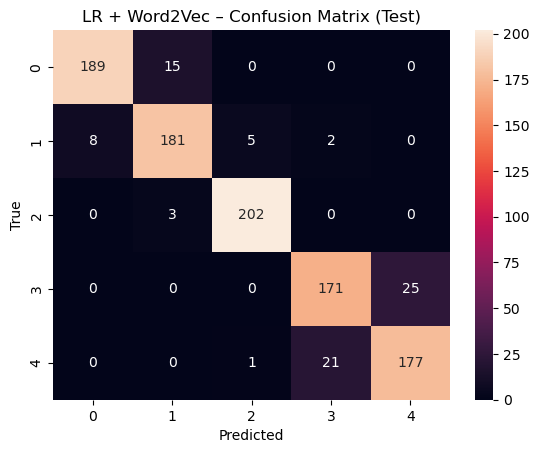


Classification Report (Test, LR + Word2Vec):
              precision    recall  f1-score   support

           1       0.96      0.93      0.94       204
           2       0.91      0.92      0.92       196
           3       0.97      0.99      0.98       205
           4       0.88      0.87      0.88       196
           5       0.88      0.89      0.88       199

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000


=== Multinomial Naive Bayes + Word2Vec (shifted vectors) ===
Validation accuracy: 0.794
Validation F1-macro: 0.7904384887245348

Test accuracy: 0.769
Test F1-macro: 0.7655542517445679

Confusion Matrix (Test, NB + Word2Vec):
[[178  25   0   0   1]
 [ 32 136  23   1   4]
 [  1  12 188   3   1]
 [  0   1   5 125  65]
 [  1   3   3  50 142]]


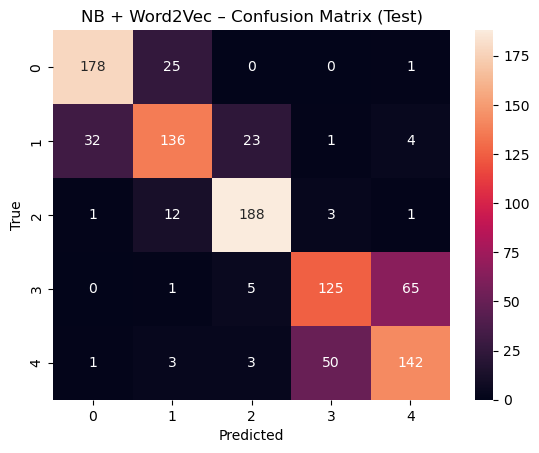


Classification Report (Test, NB + Word2Vec):
              precision    recall  f1-score   support

           1       0.84      0.87      0.86       204
           2       0.77      0.69      0.73       196
           3       0.86      0.92      0.89       205
           4       0.70      0.64      0.67       196
           5       0.67      0.71      0.69       199

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



In [14]:
# =========================
# Step 8C: Word2Vec + Logistic Regression & MultinomialNB
# =========================

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# -------- Logistic Regression + Word2Vec --------
lr_w2v = LogisticRegression(C=10, max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)

y_val_pred_lr_w2v = lr_w2v.predict(X_val_w2v)
y_test_pred_lr_w2v = lr_w2v.predict(X_test_w2v)

print("=== Logistic Regression + Word2Vec ===")
print("Validation accuracy:", accuracy_score(y_val, y_val_pred_lr_w2v))
print("Validation F1-macro:", f1_score(y_val, y_val_pred_lr_w2v, average="macro"))
print("\nTest accuracy:", accuracy_score(y_test, y_test_pred_lr_w2v))
print("Test F1-macro:", f1_score(y_test, y_test_pred_lr_w2v, average="macro"))

cm_lr_w2v = confusion_matrix(y_test, y_test_pred_lr_w2v)
print("\nConfusion Matrix (Test, LR + Word2Vec):")
print(cm_lr_w2v)

plt.figure()
sns.heatmap(cm_lr_w2v, annot=True, fmt="d")
plt.title("LR + Word2Vec – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Test, LR + Word2Vec):")
print(classification_report(y_test, y_test_pred_lr_w2v))

# -------- Multinomial Naive Bayes + Word2Vec (with non-negative shift) --------
# NB מניח פיצ'רים אי-שליליים (Counts/TF-IDF),
# לכן נבצע הסטת המימדים כך שיהיו חיוביים.

eps = 1e-6
min_val = min(X_train_w2v.min(), X_val_w2v.min(), X_test_w2v.min())

X_train_w2v_shift = X_train_w2v - min_val + eps
X_val_w2v_shift   = X_val_w2v   - min_val + eps
X_test_w2v_shift  = X_test_w2v  - min_val + eps

nb_w2v = MultinomialNB()
nb_w2v.fit(X_train_w2v_shift, y_train)

y_val_pred_nb_w2v = nb_w2v.predict(X_val_w2v_shift)
y_test_pred_nb_w2v = nb_w2v.predict(X_test_w2v_shift)

print("\n=== Multinomial Naive Bayes + Word2Vec (shifted vectors) ===")
print("Validation accuracy:", accuracy_score(y_val, y_val_pred_nb_w2v))
print("Validation F1-macro:", f1_score(y_val, y_val_pred_nb_w2v, average="macro"))
print("\nTest accuracy:", accuracy_score(y_test, y_test_pred_nb_w2v))
print("Test F1-macro:", f1_score(y_test, y_test_pred_nb_w2v, average="macro"))

cm_nb_w2v = confusion_matrix(y_test, y_test_pred_nb_w2v)
print("\nConfusion Matrix (Test, NB + Word2Vec):")
print(cm_nb_w2v)

plt.figure()
sns.heatmap(cm_nb_w2v, annot=True, fmt="d")
plt.title("NB + Word2Vec – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Test, NB + Word2Vec):")
print(classification_report(y_test, y_test_pred_nb_w2v))


## Precision & Recall Calculation for LR and NB
בשלב זה מחושבים מדדי Precision ו־Recall עבור שני המודלים (Logistic Regression ו־Naive Bayes) על סמך מטריצות הבלבול:

- הגדרת מטריצות הבלבול `cm_lr` ו־`cm_nb`.  
- פונקציה `precision_recall` המחזירה:
  - **Precision** – דיוק חיובי לכל מחלקה  
  - **Recall** – שיעור זיהוי חיובי אמיתי לכל מחלקה  
- חישוב המדדים עבור שני המודלים.  
- יצירת טבלת DataFrame להצגת התוצאות בצורה מסודרת.

שלב זה מאפשר להשוות את איכות הסיווג של כל מודל עבור כל אחת מהמחלקות.


In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# נשתמש בתחזיות על סט ה-Test של המודלים TF-IDF
cm_lr = confusion_matrix(y_test, y_test_pred_lr_tfidf)
cm_nb = confusion_matrix(y_test, y_test_pred_nb_tfidf)

def precision_recall(cm):
    # cm is square: rows = true labels, cols = predicted labels
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)

    return precision, recall

prec_lr, rec_lr = precision_recall(cm_lr)
prec_nb, rec_nb = precision_recall(cm_nb)

df_metrics = pd.DataFrame({
    'Class': np.arange(1, len(prec_lr) + 1),
    'LR_Precision': prec_lr,
    'LR_Recall': rec_lr,
    'NB_Precision': prec_nb,
    'NB_Recall': rec_nb
})

print(df_metrics)


   Class  LR_Precision  LR_Recall  NB_Precision  NB_Recall
0      1      0.979275   0.926471      0.895238   0.921569
1      2      0.923077   0.979592      0.914894   0.877551
2      3      0.995122   0.995122      0.990338   1.000000
3      4      0.942105   0.913265      0.812155   0.750000
4      5      0.916667   0.939698      0.771028   0.829146


## Plot Precision per Class for LR and NB
בשלב זה מוצג גרף קווי המשווה את ערכי ה־Precision של שתי המודלים:

- הגדרת רשימת המחלקות (1–5).  
- שימוש בערכי ה־Precision שחושבו עבור Logistic Regression ו־Naive Bayes.  
- ציור גרף קווי המציג את ה־Precision לכל מחלקה עבור כל מודל.  
- הוספת כותרת, תוויות צירים ו־Legend לשם בהירות.  
- הפעלת Grid לשיפור הקריאות.

הגרף מאפשר לראות בקלות באילו מחלקות כל מודל מדויק יותר.


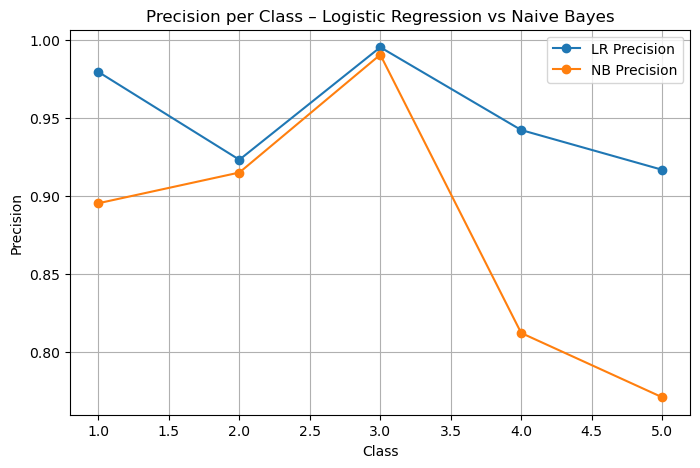

In [16]:
import matplotlib.pyplot as plt
import numpy as np

classes = [1,2,3,4,5]

prec_lr = prec_lr
prec_nb = prec_nb

plt.figure(figsize=(8,5))
plt.plot(classes, prec_lr, marker='o', label='LR Precision')
plt.plot(classes, prec_nb, marker='o', label='NB Precision')

plt.title("Precision per Class – Logistic Regression vs Naive Bayes")
plt.xlabel("Class")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


## Plot Recall per Class for LR and NB
בשלב זה מוצג גרף קווי המשווה את ערכי ה־Recall של שני המודלים:

- שימוש בערכי ה־Recall שחושבו עבור Logistic Regression ו־Naive Bayes.  
- הצגת גרף קווי עבור כל מודל לאורך מחלקות הדירוג (1–5).  
- הוספת כותרת ותוויות צירים לשם בהירות.  
- הוספת Legend להבחנה בין המודלים.  
- הפעלת Grid לשיפור קריאות הגרף.

הגרף מדגים כיצד כל מודל מזהה נכון את הדוגמאות בכל מחלקה.


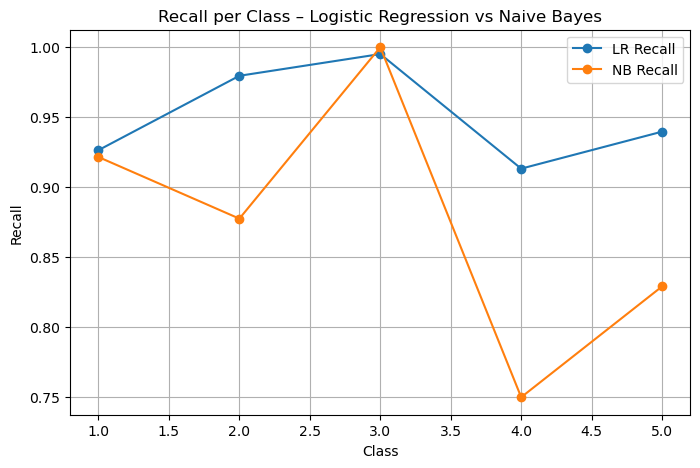

In [17]:
plt.figure(figsize=(8,5))
plt.plot(classes, rec_lr, marker='o', label='LR Recall')
plt.plot(classes, rec_nb, marker='o', label='NB Recall')

plt.title("Recall per Class – Logistic Regression vs Naive Bayes")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)
plt.show()


## Inspect Misclassified Samples – Logistic Regression (TF-IDF)
בשלב זה מזוהים ומוצגים המקרים שבהם מודל Logistic Regression טעה:

- חיזוי התוויות עבור סט הטסט (`y_pred_test`).  
- איתור האינדקסים שבהם החיזוי שונה מהדירוג האמיתי (`mis_idx`).  
- הצגת חמש הדוגמאות הראשונות שבהן המודל טעה:
  - הדירוג האמיתי  
  - החיזוי של המודל  
  - תוכן הביקורת המלא  

שלב זה מסייע בניתוח איכותי של טעויות המודל ובהבנת דפוסי השגיאה.


In [18]:
import numpy as np

y_pred_test = lr_tfidf.predict(X_test_tfidf)

mis_idx = np.where(y_pred_test != y_test)[0]

for i in mis_idx[:5]:
    print("True rating:", y_test.iloc[i], "Predicted:", y_pred_test[i])
    print("Review:")
    print(X_text_test.iloc[i])
    print("-" * 80)


True rating: 4 Predicted: 5
Review:
recently experienced delightful occasion use balloon arch partypalooza celebrate child birthday even fill laughter game magic balloon arch perfect centrepiece set tone memorable celebration particularly struck ease installation process accomplish arch time look absolutely stun impressed vibrant colour provide bring joy childrens face do upkeep durability arch superior start warp bit end night despite minor drawback highly recommend balloon arch partypalooza seek create special atmosphere celebration offer simple hasslefree solution beautiful decorative element sure enchant kid adult alike
--------------------------------------------------------------------------------
True rating: 1 Predicted: 2
Review:
dreadful experience whisker wizard product pet supply cat category disaster start finish begin annoy sound ran continuously apartment disrupt sleep inability effectively clean cat fur leave mat tangle knot thoroughly disappointed especially consider h

## Inspect Misclassified Samples – Naive Bayes (TF-IDF)
בשלב זה מוצגים המקרים שבהם מודל Multinomial Naive Bayes טעה בסיווג:

- חיזוי התוויות עבור סט הטסט באמצעות NB (`y_pred_nb`).  
- איתור האינדקסים שבהם חלה אי התאמה בין החיזוי לדירוג האמיתי (`mis_idx_nb`).  
- הדפסת חמש הדוגמאות הראשונות שבהן המודל טעה:
  - הדירוג האמיתי  
  - החיזוי של המודל  
  - הטקסט המלא של הביקורת  

הליך זה מאפשר להבין טוב יותר את מגבלות המודל ואת סוגי הביקורות שהוא מתקשה לסווג.



In [19]:
import numpy as np

y_pred_nb = nb_tfidf.predict(X_test_tfidf)

mis_idx_nb = np.where(y_pred_nb != y_test)[0]

for i in mis_idx_nb[:5]:
    print("True rating:", y_test.iloc[i], "Predicted:", y_pred_nb[i])
    print("Review:")
    print(X_text_test.iloc[i])
    print("-" * 80)


True rating: 4 Predicted: 5
Review:
really love experience libido boost new product health household sexual wellness category bit skeptical try week hooked like libido boost unique combination natural ingredient increase libido improve overall mood energy level remember flush face time felt unexpected surge desire potent ease application nongreasy texture major plus complaint forgot use rush user error product fault overall impressed result unique blend natural herb essential oil differentiate similar product market highly recommend libido boost look product address sexual wellness support overall wellbeing vitality look forward incorporate daily routine
--------------------------------------------------------------------------------
True rating: 1 Predicted: 2
Review:
absolutely hate experience harvest delight pumpkin potpourri box decorative lid poorly design cause fall easily spill entire potpourri carpet strong pungent scent remind rotten pumpkin overwhelm sensitive nose fragrance 

## Hyperparameter Tuning – Multinomial Naive Bayes (alpha)

בשלב זה נבדוק כיצד שינוי הפרמטר `alpha` (החלקה) משפיע על ביצועי המודל MultinomialNB
על ייצוג ה־TF-IDF. נשתמש בסט ה־Validation למדידה, ונחשב Accuracy ו־F1-macro לכל ערך.

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

alphas = [1.0, 0.5, 0.1]

for alpha in alphas:
    print("="*60)
    print(f"MultinomialNB with alpha = {alpha}")
    nb_model = MultinomialNB(alpha=alpha)
    nb_model.fit(X_train_tfidf, y_train)

    y_val_pred = nb_model.predict(X_val_tfidf)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")

    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation F1-macro: {f1:.4f}")
    print("Classification Report (Validation):")
    print(classification_report(y_val, y_val_pred))


MultinomialNB with alpha = 1.0
Validation Accuracy: 0.8840
Validation F1-macro: 0.8826
Classification Report (Validation):
              precision    recall  f1-score   support

           1       0.88      0.90      0.89       204
           2       0.89      0.86      0.87       195
           3       0.98      1.00      0.99       206
           4       0.85      0.80      0.82       196
           5       0.81      0.86      0.84       199

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

MultinomialNB with alpha = 0.5
Validation Accuracy: 0.8750
Validation F1-macro: 0.8738
Classification Report (Validation):
              precision    recall  f1-score   support

           1       0.88      0.88      0.88       204
           2       0.87      0.86      0.86       195
           3       0.99      0.99      0.99       206
           4       0.84      0.79      0.81     

## Hyperparameter Tuning – Logistic Regression (C)

כאן נשנה את הפרמטר `C` במודל Logistic Regression, המייצג את עוצמת הרגולריזציה:

- ערכים קטנים (C=0.1) = רגולריזציה חזקה יותר → סיכון נמוך יותר ל־overfitting.
- ערכים גדולים (C=10) = רגולריזציה חלשה יותר → המודל מתאים את עצמו יותר לנתונים.

נבדוק את ההשפעה על ביצועי המודל על סט ה־Validation.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

C_values = [0.1, 1, 10]

for C in C_values:
    print("="*60)
    print(f"Logistic Regression with C = {C}")
    lr_model = LogisticRegression(C=C, max_iter=1000)
    lr_model.fit(X_train_tfidf, y_train)

    y_val_pred = lr_model.predict(X_val_tfidf)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")

    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation F1-macro: {f1:.4f}")
    print("Classification Report (Validation):")
    print(classification_report(y_val, y_val_pred))


Logistic Regression with C = 0.1
Validation Accuracy: 0.9500
Validation F1-macro: 0.9495
Classification Report (Validation):
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       204
           2       0.97      0.92      0.94       195
           3       1.00      1.00      1.00       206
           4       0.96      0.89      0.93       196
           5       0.90      0.96      0.93       199

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

Logistic Regression with C = 1
Validation Accuracy: 0.9670
Validation F1-macro: 0.9667
Classification Report (Validation):
              precision    recall  f1-score   support

           1       0.97      0.96      0.97       204
           2       0.96      0.97      0.96       195
           3       1.00      1.00      1.00       206
           4       0.96      0.94      0.95   

In [22]:
def predict_single_review(text):
    """
    Receives a raw review text (string),
    applies the trained TF-IDF vectorizer,
    and returns the predicted rating from both LR and NB models.
    """
    X_tfidf = tfidf_vectorizer.transform([text])
    
    lr_pred = lr_tfidf.predict(X_tfidf)[0]
    
    nb_pred = nb_tfidf.predict(X_tfidf)[0]
    
    print("Input text:")
    print(text)
    print("-" * 50)
    print(f"Logistic Regression (TF-IDF) prediction: {lr_pred}")
    print(f"Naive Bayes (TF-IDF) prediction:        {nb_pred}")
    return lr_pred, nb_pred


In [26]:
test_reviews_english = [
    # Very Negative (1–2)
    "This was absolutely terrible. The room was dirty, the staff was rude, and nothing worked properly.",
    "Worst experience ever. The food was cold, tasteless, and the delivery was extremely late.",
    "A complete waste of money. I regret choosing this place and will never come back.",

    # Negative / Mixed-Low (2–3)
    "Not the worst, but definitely not worth the price. Very noisy and poorly maintained.",
    "The service was slow, and although the food was okay, it didn’t feel fresh at all.",

    # Neutral (3)
    "It was fine. Nothing special, nothing terrible. Just average overall.",
    "Decent experience. Some things were good, some were not. Could be better.",

    # Positive (4)
    "Great atmosphere, friendly staff, and clean rooms. I genuinely enjoyed my stay.",
    "Good quality and fast delivery. I’m satisfied, but the price is a bit high.",

    # Excellent (5)
    "Absolutely amazing! Everything was perfect—service, cleanliness, and overall vibe.",
    "This is the best purchase I've made this year. Outstanding quality and fast support.",
    "Perfect experience! Super clean, very professional, and everything worked flawlessly.",

    # Challenging mixed reviews
    "Great service but the food wasn’t very good. Still, I might come back.",
    "The place was beautiful, but the noise at night made it hard to sleep.",
    "I loved the design and the atmosphere, but the staff wasn’t helpful at all."
]

# Example usage:
# for review in test_reviews_english:
#     predict_single_review(review)

for s in test_reviews_english:
    print("="*70)
    predict_single_review(s)
    print("\n")




Input text:
This was absolutely terrible. The room was dirty, the staff was rude, and nothing worked properly.
--------------------------------------------------
Logistic Regression (TF-IDF) prediction: 1
Naive Bayes (TF-IDF) prediction:        1


Input text:
Worst experience ever. The food was cold, tasteless, and the delivery was extremely late.
--------------------------------------------------
Logistic Regression (TF-IDF) prediction: 2
Naive Bayes (TF-IDF) prediction:        1


Input text:
A complete waste of money. I regret choosing this place and will never come back.
--------------------------------------------------
Logistic Regression (TF-IDF) prediction: 1
Naive Bayes (TF-IDF) prediction:        1


Input text:
Not the worst, but definitely not worth the price. Very noisy and poorly maintained.
--------------------------------------------------
Logistic Regression (TF-IDF) prediction: 4
Naive Bayes (TF-IDF) prediction:        1


Input text:
The service was slow, and althou